In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import numpy.linalg as LA
import scipy.constants as const
from scipy.spatial.transform import Rotation

import matplotlib.pyplot as plt
%matplotlib ipympl


import sys
sys.path.append('E:/google-drive/py_projects/satellites/src')
# import satellites as sat
import stateest as se


In [2]:
rng = np.random.default_rng(seed=2318)


# Example: tracking 1D position with constant velocity

Estimates: ['53.96', '57.36', '59.06', '60.83', '63.18', '65.14', '66.14', '67.91', '70.85', '72.75', '74.13', '76.63', '78.90', '81.01', '82.72', '83.42', '87.77', '89.46', '91.57', '92.22']


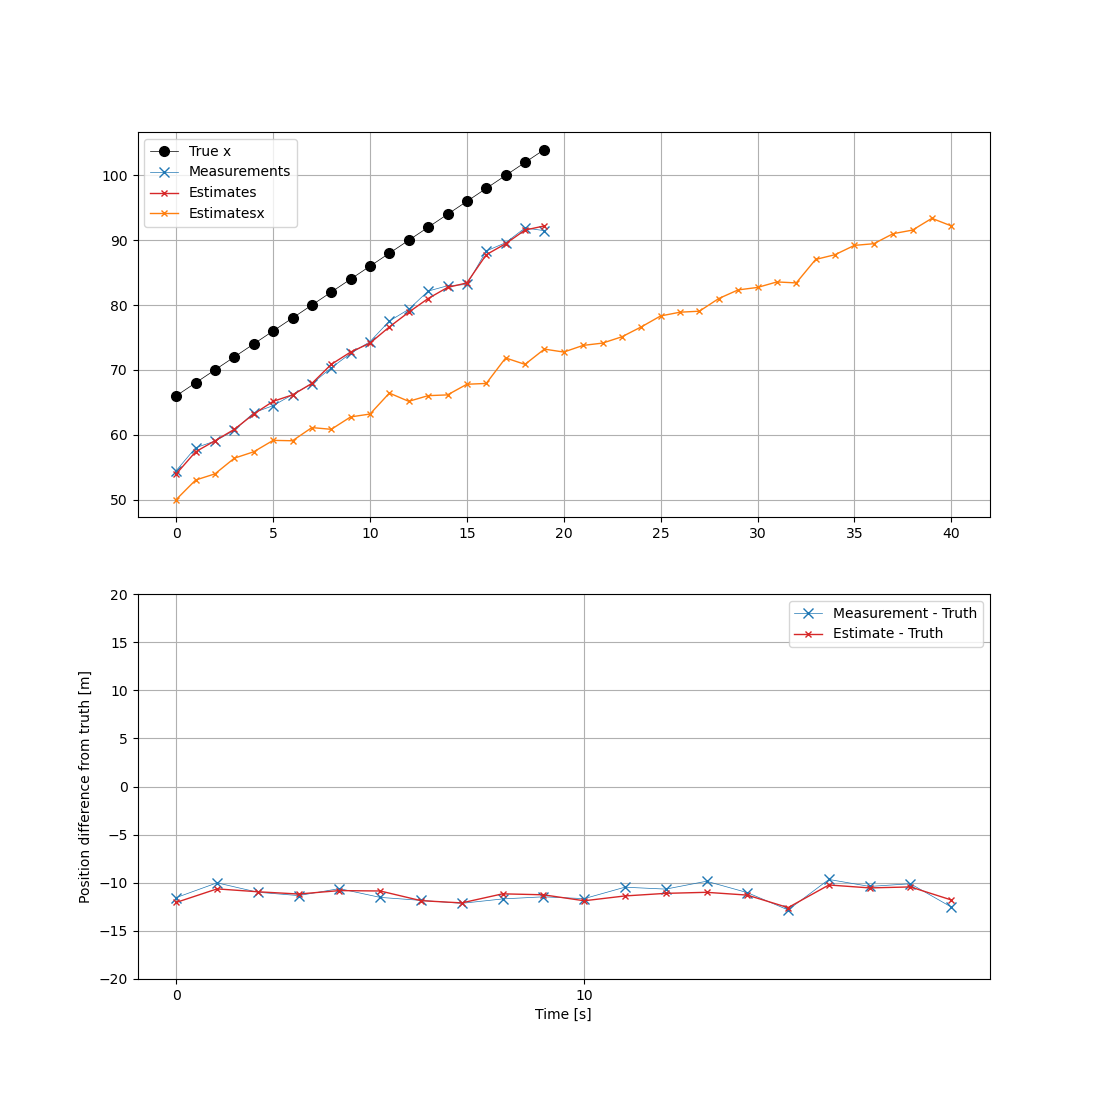

In [ ]:

dt = 1.0

F = np.array([[1, dt],
              [0,  1]])       # state: [position, velocity]

H = np.array([[1, 0],
              [0, 1]])       # measurement process

Q = np.array([[1, 0],
              [0, 100]]) * 0.1 # process noise

R = np.array([[1.0, 0],
              [0, 1]]) # measurement noise

# initial state
x0 = np.array([[50],
               [3]])
P0 = np.array([
    [1, 0],
    [0, 1],
])         # high initial uncertainty
# controls
B = np.eye(2)
u = np.zeros_like(x0)

# init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

# Simulate some noisy measurements
timevec = np.arange(20) * dt
vtrue = 2
true_positions = vtrue * timevec + 66
xmeas = true_positions - 11 + rng.normal(0, 1, true_positions.shape) 
vmeas = rng.normal(vtrue, 1, true_positions.shape)
measurements = np.vstack((xmeas, vmeas)).T
estimates = []
for z in measurements:
    # kf.model_predition_step()
    # x_est, _ = kf.measurement_update_step(np.array([[z]]), {'stable':True})
    x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})
    estimates.append(x_est[0, 0])

print("Estimates:", [f"{e:.2f}" for e in estimates])

estimatesxv = np.reshape(kf.x,[-1,2])


fig, axs = plt.subplots(2,1, figsize=[11,11])
axs[0].plot(timevec, true_positions, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[0].plot(timevec, measurements[:,0], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[0].plot(timevec, estimates, lw=1, marker='x', ms=5, color='tab:red', label='Estimates')
axs[0].plot(estimatesxv[:,0], lw=1, marker='x', ms=5, color='tab:orange', label='Estimatesx')
axs[0].legend()
axs[1].plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
axs[1].plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
axs[1].legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
axs[1].set(**axkwargs)
for ax in axs:
    ax.grid(True)
plt.show()

In [77]:
measurements.shape

(20, 2)

In [4]:
plt.close('all')

In [81]:
ellipse_vecs = []
for P in kf.P:
    evals, evecs = LA.eig(P)
    ibig = np.argmax(evals)
    ismall = 1 - ibig

    vmajor = np.reshape(np.sqrt(evals[ibig]) * evecs[:, ibig], [-1,1])
    vminor = np.reshape(np.sqrt(evals[ismall]) * evecs[:, ismall], [-1,1])
    ellipse_vecs.append( [vmajor, vminor])


In [53]:
def gen_ellipse(u, v):
    thvec = np.linspace(0, 2*const.pi, 25)
    xypts = np.cos(thvec) * u + np.sin(thvec) * v
    return xypts


In [54]:
gen_ellipse(*ellipse_vecs[11])

array([[ 1.18016289,  1.09833276,  0.94165306,  0.72080126,  0.45082805,
         0.15013165, -0.16079597, -0.46076562, -0.72933484, -0.94820111,
        -1.10244903, -1.18156688, -1.18016289, -1.09833276, -0.94165306,
        -0.72080126, -0.45082805, -0.15013165,  0.16079597,  0.46076562,
         0.72933484,  0.94820111,  1.10244903,  1.18156688,  1.18016289],
       [ 0.47954358,  0.56562365,  0.6131574 ,  0.61890548,  0.58247619,
         0.5063521 ,  0.39572095,  0.25812207,  0.10293261, -0.05927155,
        -0.21743645, -0.36078341, -0.47954358, -0.56562365, -0.6131574 ,
        -0.61890548, -0.58247619, -0.5063521 , -0.39572095, -0.25812207,
        -0.10293261,  0.05927155,  0.21743645,  0.36078341,  0.47954358]])

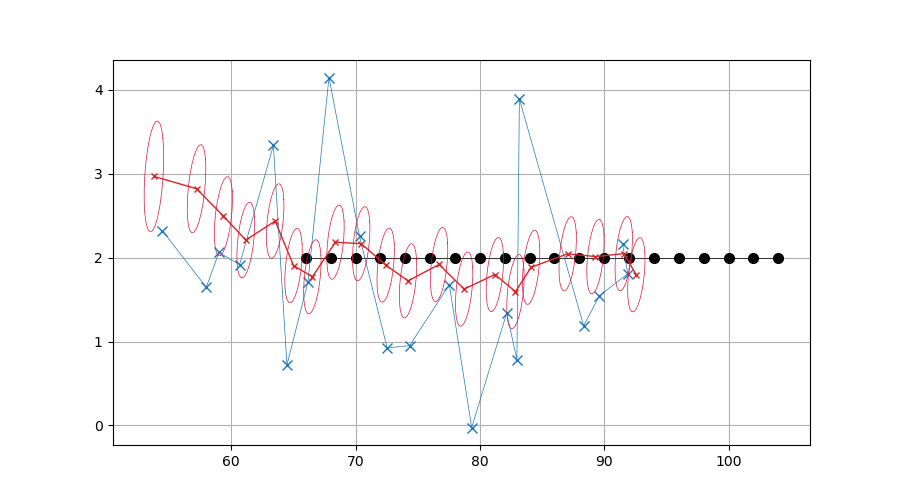

In [85]:


fig, ax = plt.subplots(1,1, figsize=[9,5], squeeze=True)
ax.plot(true_positions, vtrue*np.ones_like(true_positions), lw=0.5, marker='o', ms=7, color='k', label='True x')
ax.plot( measurements[:,0], measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot( estimatesxv[2::2,0], estimatesxv[2::2,1], lw=1, marker='x', ms=5, color='tab:red', label='Estimates')

for vs, est in zip(ellipse_vecs[2::2], estimatesxv[2::2]):
    xy = gen_ellipse(*vs) + est.reshape([-1,1])
    ax.plot(xy[0], xy[1], lw=0.5, color='crimson')
# ax.legend()
# ax.plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
# ax.plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
# ax.legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
# axs[1].set(**axkwargs)
ax.grid(True)

plt.show()

In [38]:
estimatesxv[::2].shape

(11, 2)

# Example: constant acceleration

Estimates: ['51.79', '52.63', '53.93', '54.82', '55.11', '55.45', '55.62', '56.10', '55.76', '55.58', '55.59', '56.44', '56.84', '57.76', '57.73', '57.88', '58.57', '59.63', '60.41', '61.34', '62.78', '63.56', '65.19', '67.22', '68.59', '70.16', '71.50', '73.19', '75.78', '78.64', '80.89', '83.42', '86.40', '89.68', '93.75', '96.89', '101.03', '105.02', '109.44', '113.94', '118.67', '123.75', '128.89', '133.87', '139.26', '145.76', '151.92', '158.20', '165.01', '172.11', '179.32', '186.69', '194.12', '201.98', '210.31', '219.08', '228.51', '237.40', '246.85', '256.69', '266.29', '275.98', '286.59', '297.23', '308.07', '319.50', '331.56', '343.19', '355.22', '367.57', '379.88', '392.93', '405.90', '419.06', '432.38', '446.47', '460.73', '475.38', '489.82', '504.65', '519.81', '535.43', '551.23', '567.44', '583.79', '600.08', '616.66', '633.56', '650.63', '667.45', '684.88', '702.41', '720.60', '738.92', '756.80', '774.83', '793.39', '812.51', '831.77', '850.10']


NameError: name 'estimatesxv' is not defined

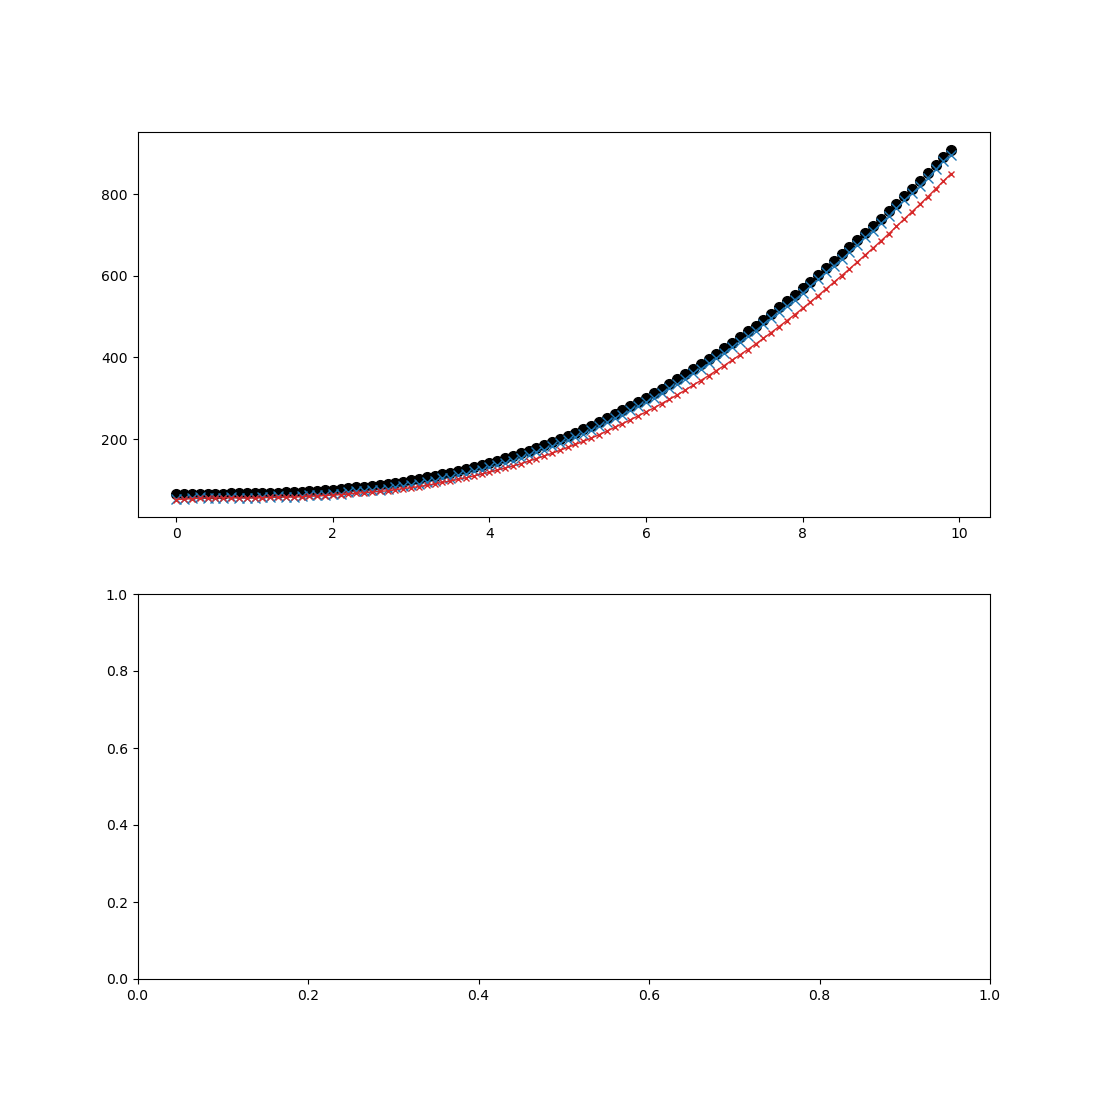

In [6]:

dt = 0.10

F = np.array([[1, dt, 0.5 * dt**2],
              [0, 1, dt],
              [0, 0, 1]])       # state: [position, velocity]

H = np.array([[1, 0, 0],
              [0, 1, 0]])       # measurement process

Q = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1]]) * 0.1 # process noise

R = np.array([[1.0, 0],
              [0, 1]]) # measurement noise

# initial state
x0 = np.array([[50],
               [3],
               [0]])
P0 = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1] ])         # high initial uncertainty
# controls
B = np.eye(2)
u = np.zeros_like(x0)

# init Kalman filter
kf = se.KalmanFilter(x0, P0, F, B, u, Q, H, R )

# Simulate some noisy measurements
timevec = np.arange(100) * dt
vtrue = 2 * np.sin(2*const.pi*timevec/35)
true_positions = np.cumsum(vtrue * timevec) + 66
xmeas = true_positions - 11 + rng.normal(0, 1, true_positions.shape) 
vmeas = rng.normal(vtrue, 1, true_positions.shape)
measurements = np.vstack((xmeas, vmeas)).T
estimates = []
estimatesv = []
for z in measurements:
    # kf.model_predition_step()
    # x_est, _ = kf.measurement_update_step(np.array([[z]]), {'stable':True})
    x_est, _ = kf.perform_epoch(u=None, z=z.reshape([-1,1]), postcovkwargs={'stable':True})
    estimates.append(x_est[0, 0])
    estimatesv.append(x_est[1, 0])

print("Estimates:", [f"{e:.2f}" for e in estimates])

estimatesxva = np.reshape(kf.x,[-1,3])


fig, axs = plt.subplots(2,1, figsize=[11,11])
axs[0].plot(timevec, true_positions, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[0].plot(timevec, measurements[:,0], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[0].plot(timevec, estimates, lw=1, marker='x', ms=5, color='tab:red', label='Estimates')
axs[0].plot(estimatesxv[2::2,0], lw=1, marker='x', ms=5, color='tab:orange', label='Estimatesx')
axs[0].legend()
axs[1].plot(timevec, vtrue, lw=0.5, marker='o', ms=7, color='k', label='True x')
axs[1].plot(timevec, measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
axs[1].plot(timevec, estimatesv, lw=1, marker='x', ms=5, color='tab:red', label='Estimates')
axs[1].plot(estimatesxv[2::2,0], lw=1, marker='x', ms=5, color='tab:orange', label='Estimatesx')
axs[1].legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
axs[1].set(**axkwargs)
for ax in axs:
    ax.grid(True)
plt.show()

In [97]:
rng.normal(vtrue, 3).shape

(200,)

NameError: name 'estimatesxv' is not defined

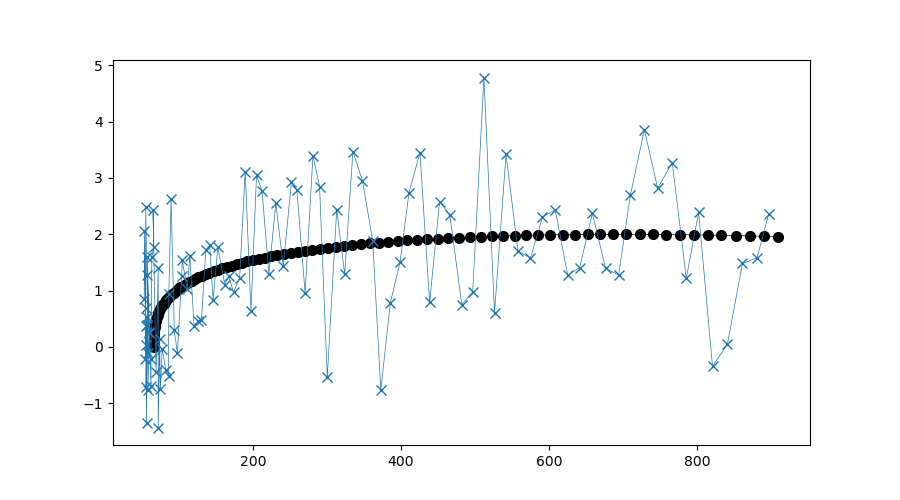

In [7]:


fig, ax = plt.subplots(1,1, figsize=[9,5], squeeze=True)
ax.plot(true_positions, vtrue*np.ones_like(true_positions), lw=0.5, marker='o', ms=7, color='k', label='True x')
ax.plot( measurements[:,0], measurements[:,1], lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurements')
ax.plot( estimatesxv[2::2,0], estimatesxv[2::2,1], lw=1, marker='x', ms=5, color='tab:red', label='Estimates')

for vs, est in zip(ellipse_vecs[2::2], estimatesxv[2::2]):
    xy = gen_ellipse(*vs) + est.reshape([-1,1])
    ax.plot(xy[0], xy[1], lw=0.5, color='crimson')
# ax.legend()
# ax.plot(timevec, measurements[:,0] - true_positions, lw=0.5, marker='x', ms=7, color='tab:blue', label='Measurement - Truth')
# ax.plot(timevec, estimates - true_positions, lw=1, marker='x', ms=5, color='tab:red', label='Estimate - Truth')
# ax.legend()

axkwargs = {
    'xticks': timevec[::10],
    'ylim': [-20, 20],
    'xlabel': 'Time [s]',
    'ylabel': 'Position difference from truth [m]',
}
# axs[1].set(**axkwargs)
ax.grid(True)

plt.show()